# 🔧 Predictive Maintenance: LSTM Model Training

**Pipeline Overview:**
1. **EDA** - Exploratory Data Analysis
2. **Preprocessing** - Data Cleaning & Feature Engineering
3. **SMOTE** - Handle Class Imbalance
4. **Sequence Creation** - Prepare data for LSTM
5. **Model Training** - Train LSTM with validation
6. **Evaluation** - Performance metrics & visualization

---
# Part 1: Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Paths
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_FILE = os.path.join(DATA_DIR, 'labeled_dataset.csv')
PROCESSED_FILE = os.path.join(DATA_DIR, 'processed_dataset.csv')
PREPROCESSED_DIR = os.path.join(DATA_DIR, 'preprocessed')

print(f"Data directory: {DATA_DIR}")

Data directory: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\data


---
# Part 2: Exploratory Data Analysis (EDA)

## 2.1 Load Raw Data

In [2]:
df_raw = pd.read_csv(RAW_FILE)
print(f"Dataset Shape: {df_raw.shape}")
print(f"Total Records: {len(df_raw):,}")
df_raw.head()

Dataset Shape: (39259, 11)
Total Records: 39,259


,NO,Timestamp,Service Type,Service Name,Type,Status,SLA (minutes),Resolved Time,Resolved Duration (minutes),Month,label
0,2045,2024-01-01 08:13:45,Inbound,Inbound Contact Center,Restoration,Closed,45.0,2024-01-01 08:48:06,"33,12",Jan,1
1,2566,2024-01-10 15:06:49,-,-,Restoration,Closed,90.0,2024-01-11 16:10:11,"12,33",Jan,1
2,2268,2024-01-05 06:11:00,-,-,Restoration,Closed,210.0,2024-01-05 06:54:47,"34,30",Jan,0
3,2560,2024-01-10 14:19:44,-,-,Restoration,Closed,210.0,2024-01-10 16:13:57,"15,73",Jan,0
4,2558,2024-01-10 14:02:29,Sosiomedio,Sosiomedio,Restoration,Closed,210.0,2024-01-10 16:14:56,"26,33",Jan,0


## 2.2 Data Overview

In [3]:
print("=" * 60)
print("DATA INFO")
print("=" * 60)
df_raw.info()

DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39259 entries, 0 to 39258
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   NO                           39259 non-null  int64  
 1   Timestamp                    39259 non-null  object 
 2   Service Type                 37747 non-null  object 
 3   Service Name                 37860 non-null  object 
 4   Type                         39259 non-null  object 
 5   Status                       39259 non-null  object 
 6   SLA (minutes)                33679 non-null  float64
 7   Resolved Time                39259 non-null  object 
 8   Resolved Duration (minutes)  39259 non-null  object 
 9   Month                        39259 non-null  object 
 10  label                        39259 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 3.3+ MB


In [4]:
print("=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df_raw.describe()

STATISTICAL SUMMARY


,NO,SLA (minutes),label
count,39259.000000,33679.000000,39259.000000
mean,6168.979572,10237.591645,0.311648
std,6035.868481,22200.551910,0.463173
min,1.000000,0.000000,0.000000
25%,1640.000000,180.000000,0.000000
50%,3308.000000,210.000000,0.000000
75%,10404.500000,4320.000000,1.000000
max,20729.000000,86400.000000,1.000000


## 2.3 Missing Values Analysis

Missing Values Summary:


,Column,Missing Count,Missing %
6,SLA (minutes),5580,14.21
2,Service Type,1512,3.85
3,Service Name,1399,3.56


C:\Users\Mahesa\AppData\Local\Temp\ipykernel_28752\1418851969.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df[missing_df['Missing Count'] > 0],


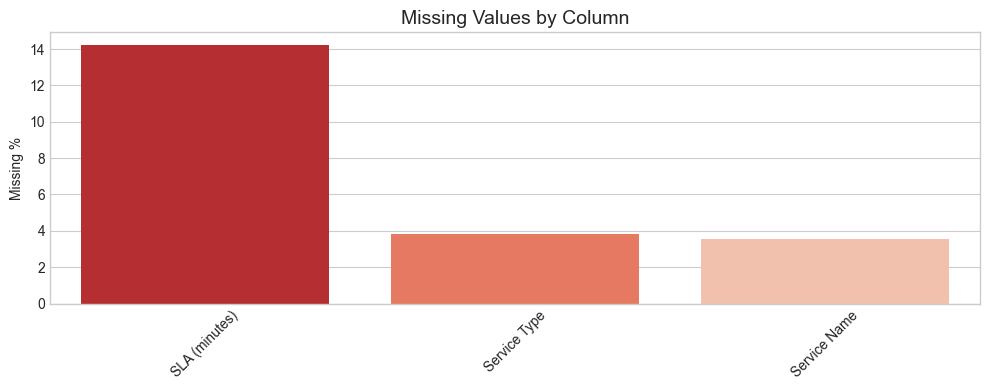

In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
}).sort_values('Missing Count', ascending=False)

print("Missing Values Summary:")
display(missing_df[missing_df['Missing Count'] > 0])

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
cols_with_missing = missing_df[missing_df['Missing Count'] > 0]['Column'].values
if len(cols_with_missing) > 0:
    sns.barplot(data=missing_df[missing_df['Missing Count'] > 0], 
                x='Column', y='Missing %', ax=ax, palette='Reds_r')
    ax.set_title('Missing Values by Column', fontsize=14)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("✅ No missing values!")

## 2.4 Target Variable Distribution (Class Imbalance)

Target Variable Distribution:
  Class 0 (No Failure): 27,024 (68.84%)
  Class 1 (Failure):    12,235 (31.16%)
  Imbalance Ratio:      2.21:1


C:\Users\Mahesa\AppData\Local\Temp\ipykernel_28752\141708934.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['No Failure (0)', 'Failure (1)'], y=label_counts.values,


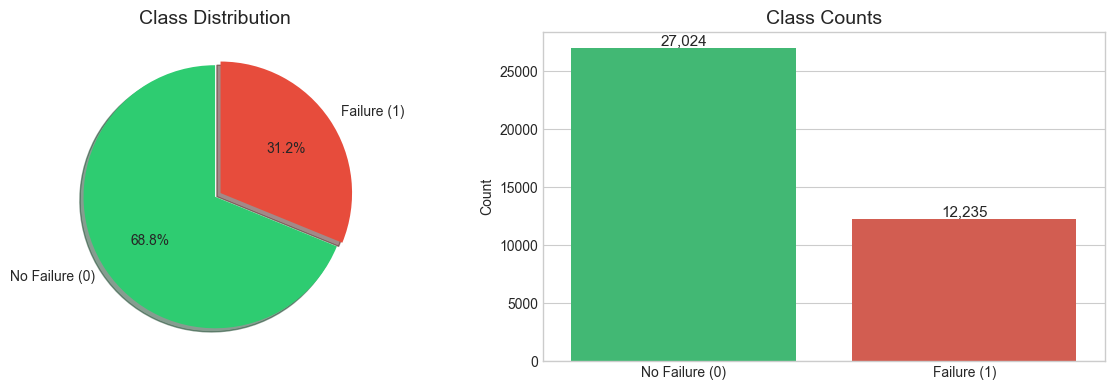


⚠️ Dataset is IMBALANCED - Will apply SMOTE later


In [6]:
label_counts = df_raw['label'].value_counts()
label_pct = df_raw['label'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(f"  Class 0 (No Failure): {label_counts[0]:,} ({label_pct[0]:.2f}%)")
print(f"  Class 1 (Failure):    {label_counts[1]:,} ({label_pct[1]:.2f}%)")
print(f"  Imbalance Ratio:      {label_counts[0]/label_counts[1]:.2f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(label_counts, labels=['No Failure (0)', 'Failure (1)'], 
            autopct='%1.1f%%', colors=colors, explode=[0, 0.05],
            shadow=True, startangle=90)
axes[0].set_title('Class Distribution', fontsize=14)

# Bar chart
sns.barplot(x=['No Failure (0)', 'Failure (1)'], y=label_counts.values, 
            palette=colors, ax=axes[1])
axes[1].set_ylabel('Count')
axes[1].set_title('Class Counts', fontsize=14)
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\n⚠️ Dataset is IMBALANCED - Will apply SMOTE later")

## 2.5 Categorical Features Analysis

In [7]:
cat_cols = ['Service Type', 'Service Name', 'Type', 'Status', 'Month']

print("Unique Values per Categorical Column:")
for col in cat_cols:
    if col in df_raw.columns:
        print(f"  {col}: {df_raw[col].nunique()} unique values")

Unique Values per Categorical Column:
  Service Type: 76 unique values
  Service Name: 110 unique values
  Type: 2 unique values
  Status: 4 unique values
  Month: 10 unique values


C:\Users\Mahesa\AppData\Local\Temp\ipykernel_28752\3021889299.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.values, y=type_counts.index, ax=axes[0,0], palette='viridis')
C:\Users\Mahesa\AppData\Local\Temp\ipykernel_28752\3021889299.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.values, y=status_counts.index, ax=axes[0,1], palette='coolwarm')
C:\Users\Mahesa\AppData\Local\Temp\ipykernel_28752\3021889299.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, a

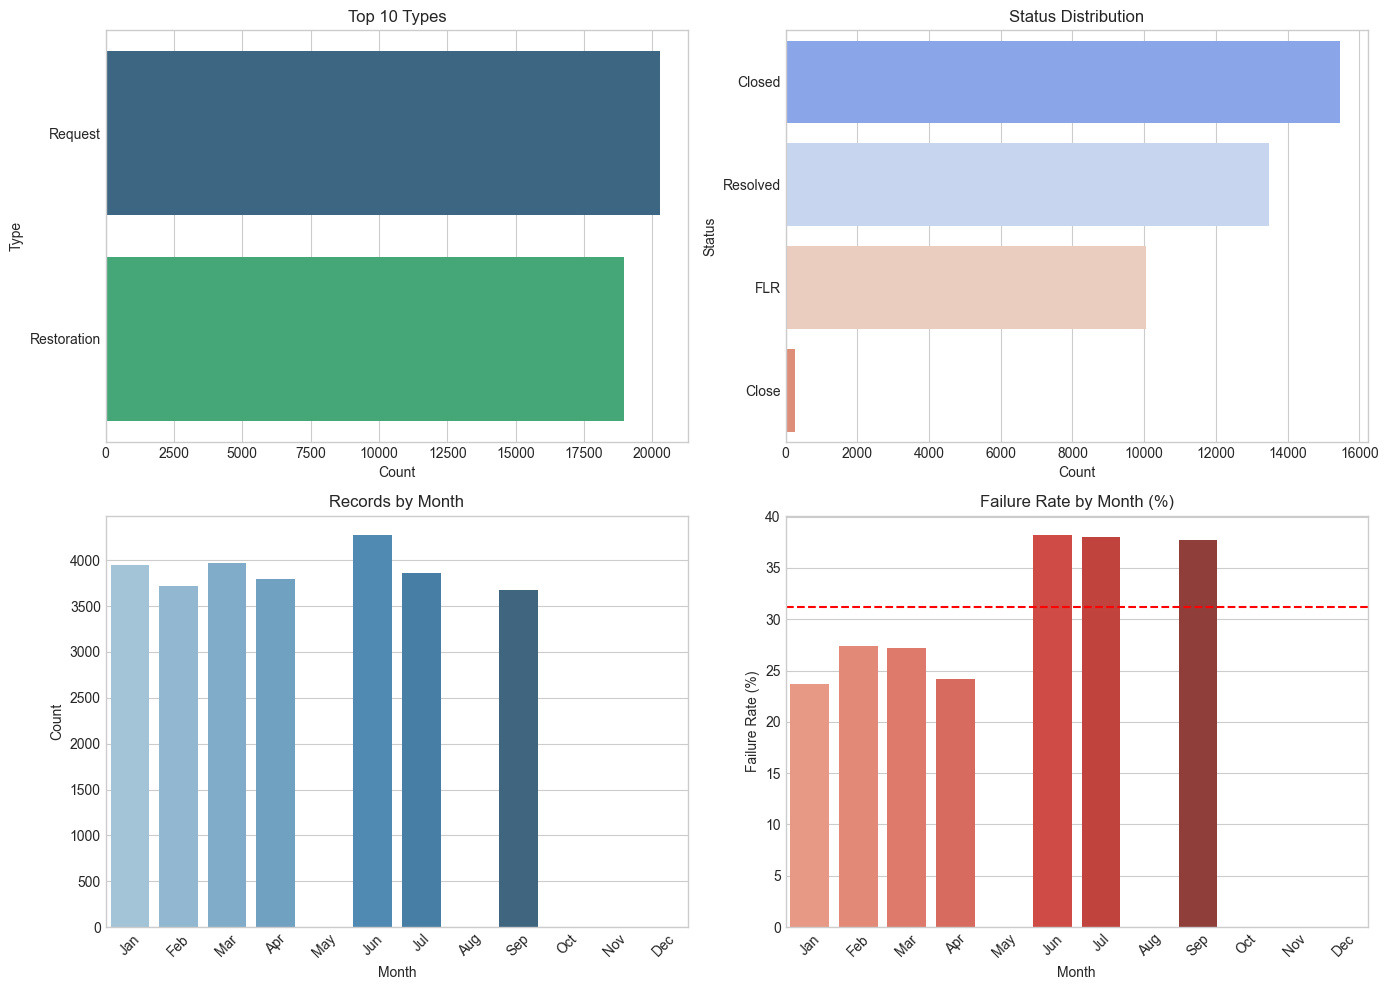

In [8]:
# Distribution of key categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Type
if 'Type' in df_raw.columns:
    type_counts = df_raw['Type'].value_counts().head(10)
    sns.barplot(x=type_counts.values, y=type_counts.index, ax=axes[0,0], palette='viridis')
    axes[0,0].set_title('Top 10 Types', fontsize=12)
    axes[0,0].set_xlabel('Count')

# Status
if 'Status' in df_raw.columns:
    status_counts = df_raw['Status'].value_counts()
    sns.barplot(x=status_counts.values, y=status_counts.index, ax=axes[0,1], palette='coolwarm')
    axes[0,1].set_title('Status Distribution', fontsize=12)
    axes[0,1].set_xlabel('Count')

# Month
if 'Month' in df_raw.columns:
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_counts = df_raw['Month'].value_counts().reindex(month_order)
    sns.barplot(x=month_counts.index, y=month_counts.values, ax=axes[1,0], palette='Blues_d')
    axes[1,0].set_title('Records by Month', fontsize=12)
    axes[1,0].set_ylabel('Count')
    axes[1,0].tick_params(axis='x', rotation=45)

# Failure rate by Month
if 'Month' in df_raw.columns:
    failure_by_month = df_raw.groupby('Month')['label'].mean().reindex(month_order) * 100
    sns.barplot(x=failure_by_month.index, y=failure_by_month.values, ax=axes[1,1], palette='Reds_d')
    axes[1,1].set_title('Failure Rate by Month (%)', fontsize=12)
    axes[1,1].set_ylabel('Failure Rate (%)')
    axes[1,1].tick_params(axis='x', rotation=45)
    axes[1,1].axhline(y=df_raw['label'].mean()*100, color='red', linestyle='--', label='Overall Avg')

plt.tight_layout()
plt.show()

## 2.6 Numerical Features Analysis

C:\Users\Mahesa\AppData\Local\Temp\ipykernel_28752\3225085810.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='label', y='SLA (minutes)', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
C:\Users\Mahesa\AppData\Local\Temp\ipykernel_28752\3225085810.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No Failure', 'Failure'])


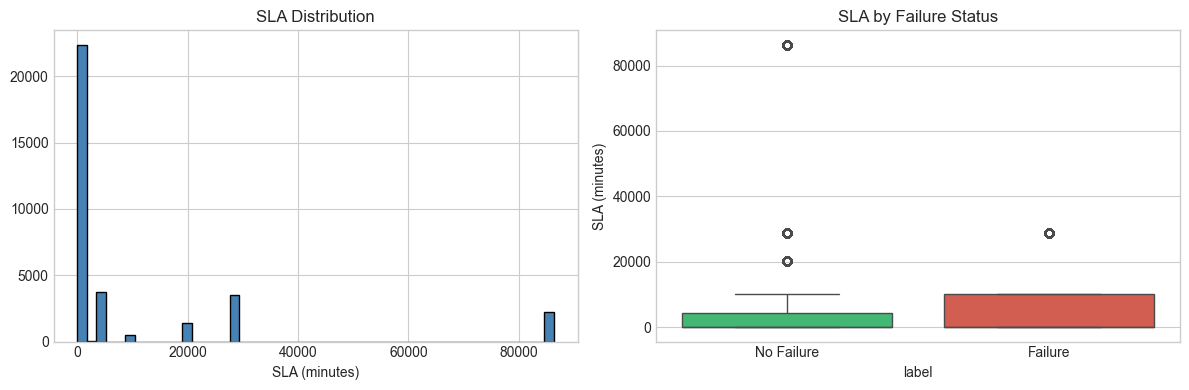

In [9]:
# SLA analysis
if 'SLA (minutes)' in df_raw.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Distribution
    df_raw['SLA (minutes)'].dropna().hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title('SLA Distribution', fontsize=12)
    axes[0].set_xlabel('SLA (minutes)')
    
    # SLA by failure
    sns.boxplot(data=df_raw, x='label', y='SLA (minutes)', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
    axes[1].set_title('SLA by Failure Status', fontsize=12)
    axes[1].set_xticklabels(['No Failure', 'Failure'])
    
    plt.tight_layout()
    plt.show()

---
# Part 3: Data Preprocessing & Cleaning

## 3.1 Initial Cleaning

In [10]:
df = df_raw.copy()
print(f"Original shape: {df.shape}")

# Drop NO column (just an ID)
if 'NO' in df.columns:
    df = df.drop('NO', axis=1)
    print("Dropped 'NO' column")

print(f"Shape after dropping ID: {df.shape}")

Original shape: (39259, 11)
Dropped 'NO' column
Shape after dropping ID: (39259, 10)


## 3.2 Handle Missing Values

In [11]:
print("Handling missing values...")

# Fill categorical with mode
for col in ['Service Type', 'Service Name']:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        missing_count = df[col].isnull().sum()
        df[col] = df[col].fillna(mode_val)
        print(f"  {col}: Filled {missing_count} missing with mode '{mode_val}'")

# Fill numerical with median
if 'SLA (minutes)' in df.columns:
    median_val = df['SLA (minutes)'].median()
    missing_count = df['SLA (minutes)'].isnull().sum()
    df['SLA (minutes)'] = df['SLA (minutes)'].fillna(median_val)
    print(f"  SLA (minutes): Filled {missing_count} missing with median {median_val}")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Handling missing values...
  Service Type: Filled 1512 missing with mode 'Inbound'
  Service Name: Filled 1399 missing with mode 'Inbound Contact Center'
  SLA (minutes): Filled 5580 missing with median 210.0

Remaining missing values: 0


## 3.3 Parse Datetime & Create Time Features

In [12]:
# Parse Timestamp
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    
    # Extract time features
    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek  # 0=Monday
    df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
    
    print("Created time features: Hour, DayOfWeek, IsWeekend")

# Parse Resolved Time
if 'Resolved Time' in df.columns:
    df['Resolved Time'] = pd.to_datetime(df['Resolved Time'], errors='coerce')

df.head()

Created time features: Hour, DayOfWeek, IsWeekend


,Timestamp,Service Type,Service Name,Type,Status,SLA (minutes),Resolved Time,Resolved Duration (minutes),Month,label,Hour,DayOfWeek,IsWeekend
0,2024-01-01 08:13:45,Inbound,Inbound Contact Center,Restoration,Closed,45.0,2024-01-01 08:48:06,"33,12",Jan,1,8,0,0
1,2024-01-10 15:06:49,-,-,Restoration,Closed,90.0,2024-01-11 16:10:11,"12,33",Jan,1,15,2,0
2,2024-01-05 06:11:00,-,-,Restoration,Closed,210.0,2024-01-05 06:54:47,"34,30",Jan,0,6,4,0
3,2024-01-10 14:19:44,-,-,Restoration,Closed,210.0,2024-01-10 16:13:57,"15,73",Jan,0,14,2,0
4,2024-01-10 14:02:29,Sosiomedio,Sosiomedio,Restoration,Closed,210.0,2024-01-10 16:14:56,"26,33",Jan,0,14,2,0


## 3.4 Parse Resolved Duration

In [13]:
# Handle Resolved Duration
if 'Resolved Duration (minutes)' in df.columns:
    # Convert to string first to handle formatting
    duration_str = df['Resolved Duration (minutes)'].astype(str)
    
    # Remove dots (thousands separators) and replace commas with dots (decimal separators)
    # Example: "8.713,37" -> "8713.37" and "33,12" -> "33.12"
    duration_cleaned = duration_str.str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    
    # Convert to numeric
    df['Resolved Duration (minutes)'] = pd.to_numeric(duration_cleaned, errors='coerce')
    
    # Fill NaN with median instead of 0
    median_val = df['Resolved Duration (minutes)'].median()
    missing_count = df['Resolved Duration (minutes)'].isnull().sum()
    df['Resolved Duration (minutes)'] = df['Resolved Duration (minutes)'].fillna(median_val)
    
    print(f"Resolved Duration stats:")
    print(f"  Filled {missing_count} missing values with median: {median_val:.2f}")
    print(df['Resolved Duration (minutes)'].describe())

Resolved Duration stats:
  Filled 0 missing values with median: 23.63


count    3.925900e+04
mean    -4.956370e+02
std      2.550665e+04
min     -1.928102e+06
25%      7.750000e+00
50%      2.363000e+01
75%      5.993000e+01
max      4.071638e+04
Name: Resolved Duration (minutes), dtype: float64


In [14]:
# Diagnostic: Verify the conversion worked correctly
print("=" * 60)
print("RESOLVED DURATION CONVERSION DIAGNOSTIC")
print("=" * 60)

# Show some original values from CSV
print("\nSample original values from CSV (before conversion):")
sample_raw = df_raw['Resolved Duration (minutes)'].head(10)
for idx, val in sample_raw.items():
    print(f"  Row {idx}: '{val}'")

# Show converted values
print("\nSample converted values (after conversion):")
sample_converted = df['Resolved Duration (minutes)'].head(10)
for idx, val in sample_converted.items():
    print(f"  Row {idx}: {val:.2f}")

# Check for any zeros that might indicate conversion failure
zero_count = (df['Resolved Duration (minutes)'] == 0).sum()
total_count = len(df['Resolved Duration (minutes)'])
print(f"\nZero values: {zero_count} out of {total_count} ({zero_count/total_count*100:.2f}%)")

# Show value range
print(f"\nValue range:")
print(f"  Min:    {df['Resolved Duration (minutes)'].min():.2f}")
print(f"  Max:    {df['Resolved Duration (minutes)'].max():.2f}")
print(f"  Mean:   {df['Resolved Duration (minutes)'].mean():.2f}")
print(f"  Median: {df['Resolved Duration (minutes)'].median():.2f}")

if df['Resolved Duration (minutes)'].mean() > 1:
    print("\n✅ SUCCESS: Values are properly converted!")
else:
    print("\n⚠️ WARNING: Values might not be converted correctly!")

RESOLVED DURATION CONVERSION DIAGNOSTIC

Sample original values from CSV (before conversion):
  Row 0: '33,12'
  Row 1: '12,33'
  Row 2: '34,30'
  Row 3: '15,73'
  Row 4: '26,33'
  Row 5: '10,42'
  Row 6: '0,50'
  Row 7: '8,92'
  Row 8: '15,73'
  Row 9: '14,32'

Sample converted values (after conversion):
  Row 0: 33.12
  Row 1: 12.33
  Row 2: 34.30
  Row 3: 15.73
  Row 4: 26.33
  Row 5: 10.42
  Row 6: 0.50
  Row 7: 8.92
  Row 8: 15.73
  Row 9: 14.32

Zero values: 26 out of 39259 (0.07%)

Value range:
  Min:    -1928101.65
  Max:    40716.38
  Mean:   -495.64
  Median: 23.63

⚠️ WARNING: Values might not be converted correctly!


## 3.5 Encode Categorical Variables

In [15]:
# Label encode categorical columns
encoders = {}
cat_cols_to_encode = ['Service Type', 'Service Name', 'Type', 'Status', 'Month']

for col in cat_cols_to_encode:
    if col in df.columns:
        le = LabelEncoder()
        df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
        print(f"Encoded {col}: {len(le.classes_)} classes")

print(f"\nNew shape: {df.shape}")

Encoded Service Type: 76 classes
Encoded Service Name: 110 classes
Encoded Type: 2 classes
Encoded Status: 4 classes
Encoded Month: 10 classes

New shape: (39259, 18)


## 3.6 Select Features for Model

In [16]:
# Select numerical features for the model
feature_cols = [
    'SLA (minutes)',
    'Resolved Duration (minutes)',
    'Hour',
    'DayOfWeek',
    'IsWeekend',
    'Service Type_encoded',
    'Service Name_encoded',
    'Type_encoded',
    'Status_encoded',
    'Month_encoded'
]

# Filter only existing columns
feature_cols = [col for col in feature_cols if col in df.columns]
print(f"Selected {len(feature_cols)} features: {feature_cols}")

# Create final dataset
df_features = df[feature_cols + ['label']].copy()

# Sort by timestamp for proper sequence creation
if 'Timestamp' in df.columns:
    df_features = df.sort_values('Timestamp')[feature_cols + ['label']].copy()

print(f"\nFinal dataset shape: {df_features.shape}")
df_features.head()

Selected 10 features: ['SLA (minutes)', 'Resolved Duration (minutes)', 'Hour', 'DayOfWeek', 'IsWeekend', 'Service Type_encoded', 'Service Name_encoded', 'Type_encoded', 'Status_encoded', 'Month_encoded']

Final dataset shape: (39259, 11)


,SLA (minutes),Resolved Duration (minutes),Hour,DayOfWeek,IsWeekend,Service Type_encoded,Service Name_encoded,Type_encoded,Status_encoded,Month_encoded,label
76,240.0,44.23,23,6,1,59,106,1,1,3,1
1512,210.0,55.10,1,0,0,29,33,1,1,3,1
1621,210.0,48.55,2,0,0,60,97,1,1,3,1
1615,60.0,43.43,5,0,0,32,59,1,1,3,1
1622,360.0,69.53,5,0,0,29,0,1,1,3,0


## 3.7 Scale Features

In [17]:
scaler = StandardScaler()

X = df_features[feature_cols].values
y = df_features['label'].values

X_scaled = scaler.fit_transform(X)

print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print(f"\nScaled feature statistics:")
print(f"  Mean: {X_scaled.mean():.4f}")
print(f"  Std:  {X_scaled.std():.4f}")

X shape: (39259, 10)


y shape: (39259,)

Scaled feature statistics:
  Mean: 0.0000
  Std:  1.0000


## 3.8 Save Processed Dataset

In [18]:
# Create DataFrame with scaled features
df_processed = pd.DataFrame(X_scaled, columns=feature_cols)
df_processed['label'] = y

# Save to CSV
df_processed.to_csv(PROCESSED_FILE, index=False)
print(f"✅ Processed dataset saved to: {PROCESSED_FILE}")
print(f"   Shape: {df_processed.shape}")
df_processed.head()

✅ Processed dataset saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\data\processed_dataset.csv
   Shape: (39259, 11)


,SLA (minutes),Resolved Duration (minutes),Hour,DayOfWeek,IsWeekend,Service Type_encoded,Service Name_encoded,Type_encoded,Status_encoded,Month_encoded,label
0,-0.410984,0.021166,2.605204,2.134105,2.852060,1.554235,2.070033,1.034234,-1.073262,-0.546109,1
1,-0.412422,0.021592,-2.673843,-1.337392,-0.350624,-0.175003,-0.150366,1.034234,-1.073262,-0.546109,1
2,-0.412422,0.021335,-2.433887,-1.337392,-0.350624,1.611877,1.796285,1.034234,-1.073262,-0.546109,1
3,-0.419614,0.021135,-1.714017,-1.337392,-0.350624,-0.002079,0.640461,1.034234,-1.073262,-0.546109,1
4,-0.405231,0.022158,-1.714017,-1.337392,-0.350624,-0.175003,-1.154108,1.034234,-1.073262,-0.546109,0


---
# Part 4: Create Sequences for LSTM

## 4.1 Define Sequence Creation Function

In [23]:
# Sequence parameters
SEQUENCE_LENGTH = 5

def create_sequences(X, y, seq_length):
    """Create sequences for LSTM input."""
    X_seq, y_seq = [], []
    
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])  # Predict next step
    
    return np.array(X_seq), np.array(y_seq)

X_sequences, y_sequences = create_sequences(X_scaled, y, SEQUENCE_LENGTH)

print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"X_sequences shape: {X_sequences.shape}")
print(f"y_sequences shape: {y_sequences.shape}")
print(f"\nClass distribution in sequences:")
print(f"  Class 0: {np.sum(y_sequences == 0):,}")
print(f"  Class 1: {np.sum(y_sequences == 1):,}")

Sequence length: 5
X_sequences shape: (39254, 5, 10)
y_sequences shape: (39254,)

Class distribution in sequences:
  Class 0: 27,023
  Class 1: 12,231


---
# Part 5: Train/Validation Split (Before SMOTE)

In [24]:
VAL_SPLIT = 0.2
RANDOM_STATE = 42

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y,
    test_size=VAL_SPLIT,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train/Val Split ({int((1-VAL_SPLIT)*100)}/{int(VAL_SPLIT*100)}) - BEFORE SMOTE:")
print(f"  Training:   {len(X_train):,} samples")
print(f"  Validation: {len(X_val):,} samples")
print(f"\nTrain class distribution (imbalanced):")
print(f"  Class 0: {np.sum(y_train == 0):,} ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"  Class 1: {np.sum(y_train == 1):,} ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"\nVal class distribution (imbalanced - kept original):")
print(f"  Class 0: {np.sum(y_val == 0):,} ({np.sum(y_val == 0)/len(y_val)*100:.1f}%)")
print(f"  Class 1: {np.sum(y_val == 1):,} ({np.sum(y_val == 1)/len(y_val)*100:.1f}%)")

Train/Val Split (80/20) - BEFORE SMOTE:
  Training:   31,407 samples
  Validation: 7,852 samples

Train class distribution (imbalanced):
  Class 0: 21,619 (68.8%)
  Class 1: 9,788 (31.2%)

Val class distribution (imbalanced - kept original):
  Class 0: 5,405 (68.8%)
  Class 1: 2,447 (31.2%)


---
# Part 6: Apply SMOTE (Only on Training Set)

In [25]:
# Apply SMOTE only on training data to prevent data leakage
print("⚠️ Applying SMOTE ONLY on training set (not validation)")
print(f"\nBefore SMOTE (Training Set):")
print(f"  Class 0: {np.sum(y_train == 0):,}")
print(f"  Class 1: {np.sum(y_train == 1):,}")
print(f"  Ratio:   {np.sum(y_train == 0) / np.sum(y_train == 1):.2f}:1")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE (Training Set):")
print(f"  Class 0: {np.sum(y_train_resampled == 0):,}")
print(f"  Class 1: {np.sum(y_train_resampled == 1):,}")
print(f"  Ratio:   {np.sum(y_train_resampled == 0) / np.sum(y_train_resampled == 1):.2f}:1")
print(f"  Total:   {len(y_train):,} → {len(y_train_resampled):,} (+{len(y_train_resampled) - len(y_train):,})")

print(f"\n✅ Validation set remains unchanged (original distribution)")
print(f"   Validation samples: {len(y_val):,}")

⚠️ Applying SMOTE ONLY on training set (not validation)

Before SMOTE (Training Set):
  Class 0: 21,619
  Class 1: 9,788
  Ratio:   2.21:1

After SMOTE (Training Set):
  Class 0: 21,619
  Class 1: 21,619
  Ratio:   1.00:1
  Total:   31,407 → 43,238 (+11,831)

✅ Validation set remains unchanged (original distribution)
   Validation samples: 7,852


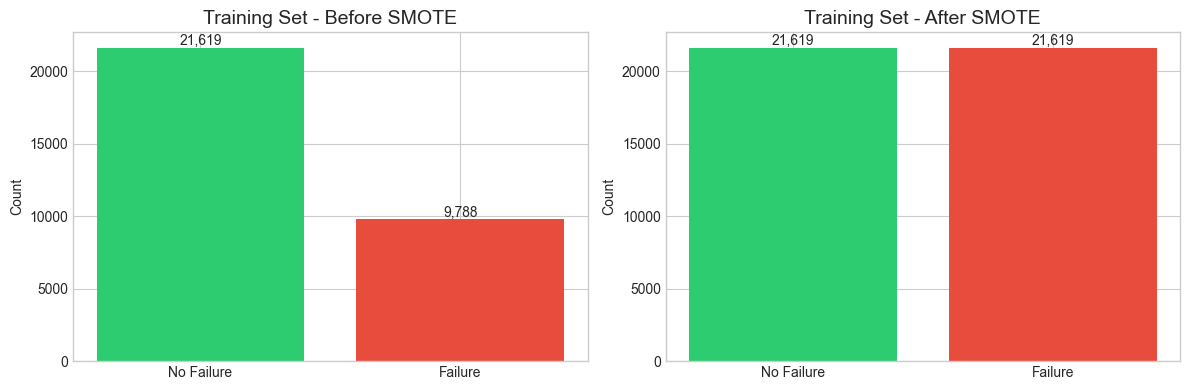


📊 Validation set keeps original imbalance for realistic evaluation


In [26]:
# Visualize before vs after SMOTE (Training Set Only)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE (Training)
before_counts = [np.sum(y_train == 0), np.sum(y_train == 1)]
axes[0].bar(['No Failure', 'Failure'], before_counts, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Training Set - Before SMOTE', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(before_counts):
    axes[0].text(i, v + 200, f'{v:,}', ha='center')

# After SMOTE (Training)
after_counts = [np.sum(y_train_resampled == 0), np.sum(y_train_resampled == 1)]
axes[1].bar(['No Failure', 'Failure'], after_counts, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Training Set - After SMOTE', fontsize=14)
axes[1].set_ylabel('Count')
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 200, f'{v:,}', ha='center')

plt.tight_layout()
plt.show()

print(f"\n📊 Validation set keeps original imbalance for realistic evaluation")

---
# Part 7: Create Sequences from Resampled Data

In [27]:
# Create sequences for training (from SMOTE-resampled data)
X_train_seq, y_train_seq = create_sequences(X_train_resampled, y_train_resampled, SEQUENCE_LENGTH)

# Create sequences for validation (from original data)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, SEQUENCE_LENGTH)

print(f"Training sequences (from SMOTE data):")
print(f"  X_train_seq shape: {X_train_seq.shape}")
print(f"  y_train_seq shape: {y_train_seq.shape}")
print(f"  Class 0: {np.sum(y_train_seq == 0):,}")
print(f"  Class 1: {np.sum(y_train_seq == 1):,}")

print(f"\nValidation sequences (from original data):")
print(f"  X_val_seq shape: {X_val_seq.shape}")
print(f"  y_val_seq shape: {y_val_seq.shape}")
print(f"  Class 0: {np.sum(y_val_seq == 0):,}")
print(f"  Class 1: {np.sum(y_val_seq == 1):,}")

Training sequences (from SMOTE data):
  X_train_seq shape: (43233, 5, 10)
  y_train_seq shape: (43233,)
  Class 0: 21,616
  Class 1: 21,617

Validation sequences (from original data):
  X_val_seq shape: (7847, 5, 10)
  y_val_seq shape: (7847,)
  Class 0: 5,402
  Class 1: 2,445


## 7.1 Save Sequences

In [28]:
# Create preprocessed directory if not exists
os.makedirs(PREPROCESSED_DIR, exist_ok=True)

# Save sequences
np.save(os.path.join(PREPROCESSED_DIR, 'X_train_sequences.npy'), X_train_seq)
np.save(os.path.join(PREPROCESSED_DIR, 'y_train_sequences.npy'), y_train_seq)
np.save(os.path.join(PREPROCESSED_DIR, 'X_val_sequences.npy'), X_val_seq)
np.save(os.path.join(PREPROCESSED_DIR, 'y_val_sequences.npy'), y_val_seq)

print(f"✅ Sequences saved to: {PREPROCESSED_DIR}")
print(f"   X_train_sequences.npy: {X_train_seq.shape}")
print(f"   y_train_sequences.npy: {y_train_seq.shape}")
print(f"   X_val_sequences.npy:   {X_val_seq.shape}")
print(f"   y_val_sequences.npy:   {y_val_seq.shape}")

✅ Sequences saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\data\preprocessed
   X_train_sequences.npy: (43233, 5, 10)
   y_train_sequences.npy: (43233,)
   X_val_sequences.npy:   (7847, 5, 10)
   y_val_sequences.npy:   (7847,)


In [ ]:
# Part 8: Model Training

In [34]:
# Import model
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
from model.lstm_cupy_optimized import LSTMModelGPUOptimized, GPU_AVAILABLE

print(f"GPU Available: {GPU_AVAILABLE}")

GPU Available: True


In [35]:
# Hyperparameters
HIDDEN_SIZE = 64
EPOCHS = 100
LEARNING_RATE = 0.001
BATCH_SIZE = 128

print("Hyperparameters:")
print(f"  Hidden Size:   {HIDDEN_SIZE}")
print(f"  Epochs:        {EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Batch Size:    {BATCH_SIZE}")

Hyperparameters:
  Hidden Size:   64
  Epochs:        100
  Learning Rate: 0.001
  Batch Size:    128


# Initialize model
input_size = X_train_seq.shape[2]
seq_len = X_train_seq.shape[1]

print(f"Model Architecture:")
print(f"  Input size:      {input_size}")
print(f"  Sequence length: {seq_len}")
print(f"  Hidden size:     {HIDDEN_SIZE}")

model = LSTMModelGPUOptimized(input_size=input_size, hidden_size=HIDDEN_SIZE)
print("\n✅ Model initialized!")

In [38]:
# Initialize model
input_size = X_train_seq.shape[2]  # Number of features
seq_len = X_train_seq.shape[1]     # Sequence length
print(f"Input size: {input_size}, Sequence length: {seq_len}")
model = LSTMModelGPUOptimized(input_size=input_size, hidden_size=HIDDEN_SIZE)
print(f"Model type: {type(model)}")

Input size: 10, Sequence length: 5
Model type: <class 'model.lstm_cupy_optimized.LSTMModelGPUOptimized'>


In [39]:
# Train
print("Starting training...\n")

history = model.train(
    X_train_seq, y_train_seq,
    X_val_seq, y_val_seq,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    print_every=10
)

Starting training...

Training: 43233 samples, 338 batches/epoch, batch_size=128
Validation: 7847 samples
----------------------------------------------------------------------
Epoch   10/100 | Train Loss: 0.6125 | Val Loss: 0.7286 | Val Acc: 0.5598 [OVERFITTING]
Epoch   20/100 | Train Loss: 0.5704 | Val Loss: 0.7230 | Val Acc: 0.5977 [OVERFITTING]
Epoch   30/100 | Train Loss: 0.5236 | Val Loss: 0.7918 | Val Acc: 0.5742 [OVERFITTING]
Epoch   40/100 | Train Loss: 0.4724 | Val Loss: 0.8684 | Val Acc: 0.5779 [OVERFITTING]
Epoch   50/100 | Train Loss: 0.4210 | Val Loss: 0.9531 | Val Acc: 0.5768 [OVERFITTING]
Epoch   60/100 | Train Loss: 0.3726 | Val Loss: 1.0656 | Val Acc: 0.5633 [OVERFITTING]
Epoch   70/100 | Train Loss: 0.3270 | Val Loss: 1.2231 | Val Acc: 0.5559 [OVERFITTING]
Epoch   80/100 | Train Loss: 0.2835 | Val Loss: 1.3834 | Val Acc: 0.5504 [OVERFITTING]
Epoch   90/100 | Train Loss: 0.2443 | Val Loss: 1.6153 | Val Acc: 0.5467 [OVERFITTING]
Epoch  100/100 | Train Loss: 0.2079 | Va

In [40]:
# Part 9: Training Visualization

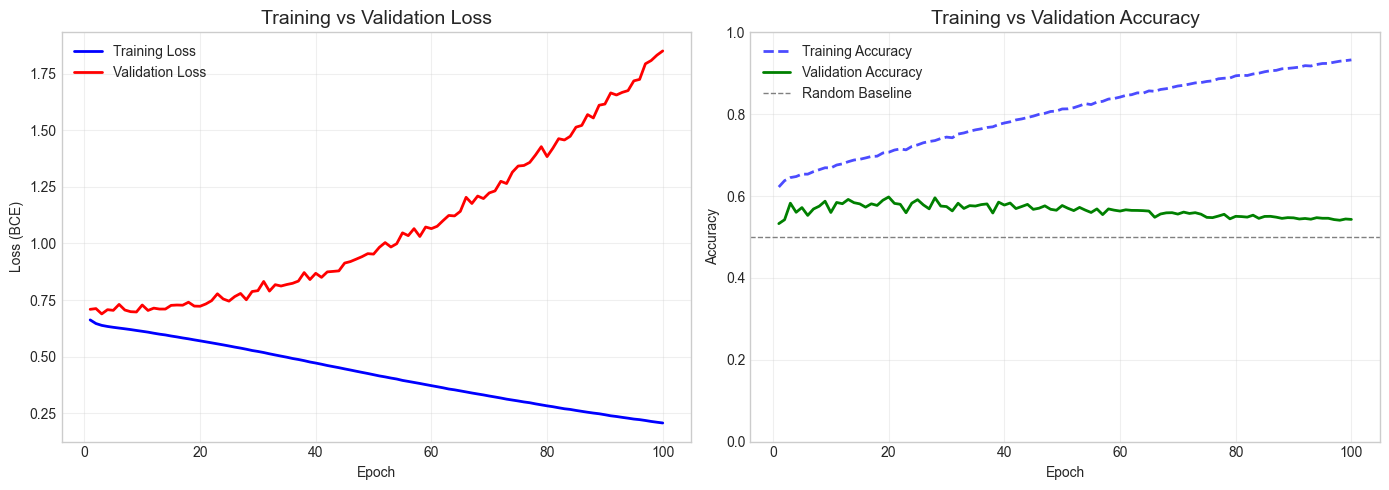

In [41]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Training vs Validation Loss', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b--', label='Training Accuracy', linewidth=2, alpha=0.7)
axes[1].plot(epochs_range, history['val_acc'], 'g-', label='Validation Accuracy', linewidth=2)
axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Random Baseline')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'training_history.png'), dpi=150)
plt.show()

---
# Part 10: Final Evaluation

In [42]:
# Final metrics
val_loss, val_acc = model.evaluate(X_val_seq, y_val_seq, batch_size=BATCH_SIZE)
print(f"Final Validation Loss:     {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")

Final Validation Loss:     1.8497
Final Validation Accuracy: 0.5429


In [43]:
# Predictions
probabilities = model.predict(X_val_seq, batch_size=BATCH_SIZE)
predictions = (probabilities >= 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_val_seq, predictions, target_names=['No Failure', 'Failure']))

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.70      0.60      0.64      5402
     Failure       0.32      0.43      0.37      2445

    accuracy                           0.54      7847
   macro avg       0.51      0.51      0.50      7847
weighted avg       0.58      0.54      0.56      7847



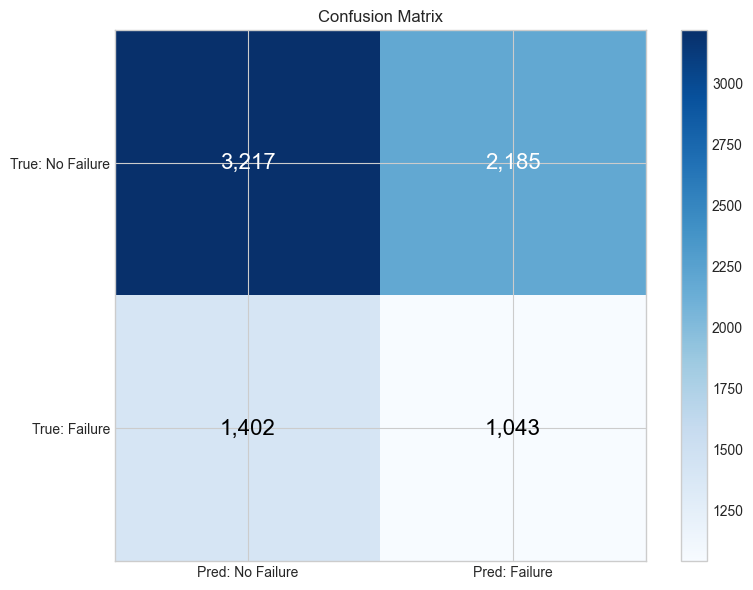

In [44]:
# Confusion Matrix
cm = confusion_matrix(y_val_seq, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=[0, 1], yticks=[0, 1],
       xticklabels=['Pred: No Failure', 'Pred: Failure'],
       yticklabels=['True: No Failure', 'True: Failure'],
       title='Confusion Matrix')

thresh = cm.max() / 2.
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black', fontsize=16)

plt.tight_layout()
plt.show()

## 10.1 Diagnosis

In [45]:
final_train_loss = history['train_loss'][-1]
final_val_loss = history['val_loss'][-1]
gap = final_val_loss - final_train_loss

print("=" * 60)
print("DIAGNOSIS")
print("=" * 60)
print(f"Final Training Loss:   {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Gap (Val - Train):     {gap:.4f}")

if val_acc < 0.6 and gap < 0.1:
    print("\n⚠️ DIAGNOSIS: UNDERFITTING")
    print("   Suggestions: Increase hidden_size, train longer, add features")
elif gap > 0.1:
    print("\n⚠️ DIAGNOSIS: OVERFITTING")
    print("   Suggestions: Add dropout, reduce hidden_size, early stopping")
else:
    print("\n✅ Model appears well-fitted")

DIAGNOSIS
Final Training Loss:   0.2079
Final Validation Loss: 1.8497
Gap (Val - Train):     1.6417

⚠️ DIAGNOSIS: OVERFITTING
   Suggestions: Add dropout, reduce hidden_size, early stopping


---
# Part 11: Save Results

In [46]:
# Save predictions
OUTPUT_FILE = os.path.join(DATA_DIR, 'predictions_gpu_optimized.csv')

results_df = pd.DataFrame({
    'actual': y_val_seq,
    'predicted': predictions,
    'probability': probabilities
})

results_df.to_csv(OUTPUT_FILE, index=False)
print(f"✅ Predictions saved to: {OUTPUT_FILE}")
results_df.head(10)

✅ Predictions saved to: c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\notebooks\..\data\predictions_gpu_optimized.csv


,actual,predicted,probability
0,0,1,0.644105
1,0,1,1.000000
2,0,1,0.999271
3,0,1,0.999829
4,0,1,0.998264
5,0,1,1.000000
6,0,0,0.000376
7,0,0,0.215935
8,1,1,0.905117
9,0,0,0.295270


In [47]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Model:              LSTM (hidden={HIDDEN_SIZE})")
print(f"GPU:                {GPU_AVAILABLE}")
print(f"SMOTE:              Applied on training set only ✓")
print(f"Training samples:   {len(X_train_seq):,}")
print(f"Validation samples: {len(X_val_seq):,}")
print(f"Final Val Accuracy: {val_acc:.4f}")
print(f"\n⚠️ No data leakage - SMOTE applied after train/test split")
print("=" * 60)

SUMMARY
Model:              LSTM (hidden=64)
GPU:                True
SMOTE:              Applied on training set only ✓
Training samples:   43,233
Validation samples: 7,847
Final Val Accuracy: 0.5429

⚠️ No data leakage - SMOTE applied after train/test split
